# 4회차 실습 과제

## 문제 항목

| 문제     | 주제                         | 핵심 개념                                                         |
|----------|------------------------------|-------------------------------------------------------------------|
| 문제 1   | 편의점 일일 매출 분석        | 정규성 검정, 단일표본 검정 (t vs Wilcoxon), 효과크기, 모수 vs 비모수 비교 |
| 문제 2   | 두 생산라인 제품 무게 비교   | 등분산 검정, 독립표본 검정 (Welch's t vs Mann-Whitney U), 이상치 영향   |
| 문제 3   | 요일별 고객 방문 패턴 분석   | 카이제곱 적합도 검정, Cohen's w, 표준화 잔차, Cochran's rule, Monte Carlo |
| 문제 4   | 연령대별 운동 선호도 조사    | 카이제곱 독립성 검정, Cramér's V, 조정된 잔차, Fisher 정확검정 (2×2)    |

---

## 핵심 공식 정리

### 가설검정 프로세스

| 단계 | 내용                                   | 비고                                          |
|------|----------------------------------------|-----------------------------------------------|
| 1    | **분석 목표** 파악                     | 무엇을 검정하려 하는지 명확히 정의합니다       |
| 2    | **가설 설정** (H₀, H₁)                | 귀무가설과 대립가설을 수식으로 표현합니다       |
| 3    | **검정 방향** 결정                     | 양측/단측 검정을 선택하고 근거를 제시합니다     |
| 4    | **가정 검정**                          | 정규성, 등분산, 기대빈도 조건 등을 확인합니다   |
| 5    | **검정 수행**                          | 가정 결과에 따라 적절한 검정을 선택합니다       |
| 6    | **효과크기** 산출                      | 통계적 유의성과 별개로 실질적 의미를 판단합니다 |
| 7    | **결론** 도출                          | p-value와 효과크기를 종합하여 해석합니다        |

> 카이제곱 검정(적합도, 독립성)은 검정 자체가 "차이 존재 여부"를 판정하므로
> 양측/단측 개념이 적용되지 않습니다 (3단계 생략).

### 양측검정 vs 단측검정

| 구분          | 양측검정 (two-sided)           | 단측검정 (one-sided)              |
|---------------|--------------------------------|-----------------------------------|
| H₁ 형태      | μ ≠ μ₀                        | μ > μ₀ 또는 μ < μ₀              |
| 사용 시기     | 방향을 사전에 특정할 수 없을 때 | 이론적·실무적 근거로 방향이 명확할 때 |
| 검정력        | 상대적으로 낮음                | 같은 α에서 더 높은 검정력         |
| 주의          | 가장 보수적이고 안전한 선택     | 사전 근거 없이 사용하면 부적절     |

### 정규성 검정

| 방법            | 판정 기준                          | 비고                              |
|-----------------|------------------------------------|-----------------------------------|
| Shapiro-Wilk    | p > 0.05 → 정규성 기각 못 함      | 소표본에 적합, 대표본에서 과민    |
| Q-Q Plot        | 점들이 대각선 위 → 정규            | 시각적 판단, Shapiro-Wilk와 함께  |

### 검정 선택 가이드 (연속형)

| 상황            | 정규성 충족                     | 정규성 위반                   |
|-----------------|---------------------------------|-------------------------------|
| 단일·대응표본   | 단일/대응표본 t-검정            | Wilcoxon signed-rank          |
| 독립 2집단      | Student's t (등분산) / Welch's t (이분산) | Mann-Whitney U        |

### 비모수 검정 효과크기

| 효과크기         | 적용 검정               | 해석 기준 (small / medium / large) |
|------------------|-------------------------|------------------------------------|
| rank-biserial r  | Wilcoxon, Mann-Whitney  | 0.1 / 0.3 / 0.5                   |

### 카이제곱 검정

| 검정           | 공식                                                          | 자유도                   |
|----------------|---------------------------------------------------------------|--------------------------|
| 적합도 검정    | $\chi^2 = \sum \frac{(O_i - E_i)^2}{E_i}$                   | $df = k - 1$            |
| 독립성 검정    | $\chi^2 = \sum \frac{(O_{ij} - E_{ij})^2}{E_{ij}}$          | $df = (r-1)(c-1)$       |
| 기대빈도       | $E_{ij} = \frac{R_i \times C_j}{N}$                          | —                        |

### 효과크기 (카이제곱)

| 효과크기     | 적용 검정      | 공식                                        | 해석 기준 (small / medium / large) |
|--------------|----------------|---------------------------------------------|------------------------------------|
| Cohen's w    | 적합도         | $\sqrt{\chi^2 / N}$                        | 0.1 / 0.3 / 0.5                   |
| Cramér's V   | 독립성         | $\sqrt{\chi^2 / (N \cdot \min(r-1, c-1))}$ | df*에 따라 다름                    |
| φ (Phi)      | 독립성 (2×2)   | $\sqrt{\chi^2 / N}$                        | 0.1 / 0.3 / 0.5                   |

### Cochran's rule (기대빈도 조건)

| 조건 | 기준                                     | 위반 시 대안                              |
|------|------------------------------------------|-------------------------------------------|
| (1)  | 기대빈도 < 5인 셀이 전체의 20% 이하     | 적합도 → Monte Carlo / 범주 병합          |
| (2)  | 기대빈도 < 1인 셀이 0개                  | 독립성(2×2) → Fisher / 독립성(R×C) → FFH  |

### 판정 규칙

| p-value 결과  | 판정             | 해석                                          |
|---------------|------------------|-----------------------------------------------|
| p ≤ α         | H₀ **기각**      | "이 결과가 우연이라고 보기 어렵습니다" → 유의   |
| p > α         | H₀ **기각 실패** | "증거 부족, 판단 보류" (H₀가 참은 아닙니다!)    |

---

In [1]:
# 필수 라이브러리 Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats
import warnings
import platform

warnings.filterwarnings('ignore')

# 운영체제별 한글 폰트 설정
if platform.system() == 'Windows':
    plt.rcParams['font.family'] = 'Malgun Gothic'
elif platform.system() == 'Darwin':
    plt.rcParams['font.family'] = 'AppleGothic'
else:
    plt.rcParams['font.family'] = 'NanumGothic'

plt.rcParams['axes.unicode_minus'] = False

print("=" * 60)
print("4회차 실습 과제: 비모수 검정, 카이제곱 검정")
print("=" * 60)


4회차 실습 과제: 비모수 검정, 카이제곱 검정


---

## 문제 1: 편의점 일일 매출 분석

한 편의점 본사는 특정 지점의 일일 매출이 전국 평균 **250만원**과 다른지 확인하려 합니다.

20일간의 매출 데이터를 수집했는데, 매출 분포가 정규분포를 따르는지 먼저 확인해야 합니다.

**분석 목표**: 이 편의점의 일일 매출이 전국 평균(250만원)과 통계적으로 유의한 차이가 있는지 검정합니다.

**주어진 데이터:**

In [2]:
print("\n[문제 1] 편의점 일일 매출 분석")
print("=" * 50)

np.random.seed(501)
daily_sales = np.round(np.random.lognormal(mean=5.5, sigma=0.3, size=20), 1)
mu0_sales = 250.0  # 전국 평균 매출 (만원)

print(f"일일 매출 데이터 (n = {len(daily_sales)}일, 단위: 만원):")
print(daily_sales)
print(f"\n표본 평균: {np.mean(daily_sales):.1f}만원")
print(f"표본 중앙값: {np.median(daily_sales):.1f}만원")
print(f"전국 평균(μ₀): {mu0_sales}만원")



[문제 1] 편의점 일일 매출 분석
일일 매출 데이터 (n = 20일, 단위: 만원):
[249.5 157.8 304.8 352.4 137.4 213.2 298.3 209.3 363.6 363.4 194.7 418.4
 207.9 250.8 206.3 372.8 367.1 355.8 214.9 207.6]

표본 평균: 272.3만원
표본 중앙값: 250.2만원
전국 평균(μ₀): 250.0만원


### 문제 1-1: 정규성 검정 (가정 검정)

**(a)** 수치적 정규성 검정(Shapiro-Wilk)을 수행하세요.

**(b)** Q-Q Plot을 그려 시각적으로 분포를 확인하세요.

**(c)** 두 결과를 종합하여 "정규분포를 따르는가?"를 판단하고,

Q-Q Plot에서 관찰되는 패턴이 어떤 분포 특성을 나타내는지 설명하세요.

In [28]:
print("\n[문제 1-1] 정규성 검정")
print("-" * 40)

# TODO (a): 정규성 검정 수행
stat_sw = stats.shapiro(daily_sales)[0]
p_sw = stats.shapiro(daily_sales)[1]

print(f"(a) 정규성 검정:")
print(f"    W = {stat_sw}")
print(f"    p-value = {p_sw}")
print(f"    판정: p-value가 유의수준보다 높은 {p_sw}이므로 귀무가설을 기각하지 못하고 정규성이 인정된다")



[문제 1-1] 정규성 검정
----------------------------------------
(a) 정규성 검정:
    W = 0.9127881381255231
    p-value = 0.07204450122682593
    판정: p-value가 유의수준보다 높은 0.07204450122682593이므로 귀무가설을 기각하지 못하고 정규성이 인정된다


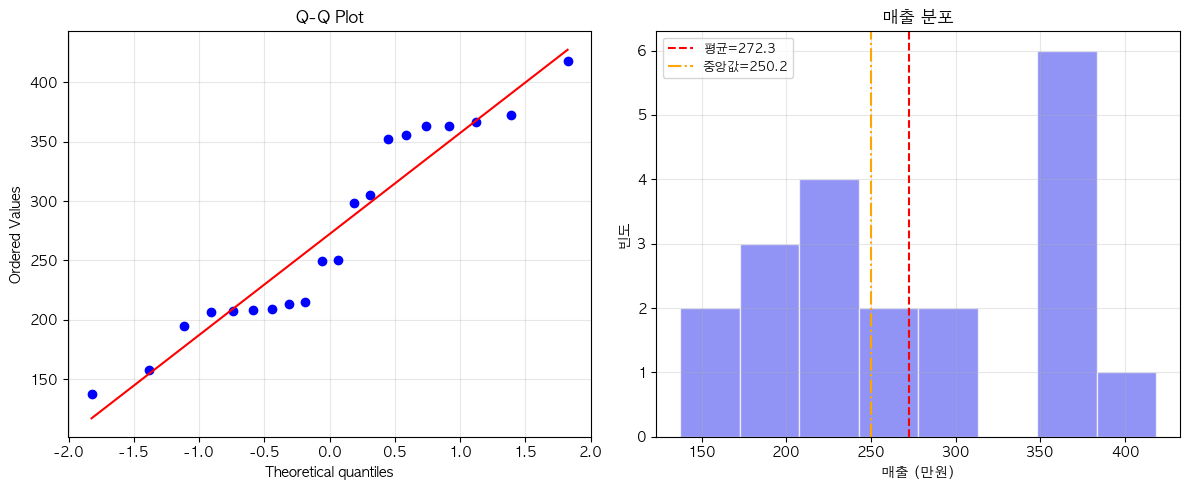

In [31]:
# TODO (b): Q-Q Plot + 히스토그램 시각화
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TODO: Q-Q Plot 그리기
stats.probplot(daily_sales, plot=axes[0])
axes[0].set_title("Q-Q Plot", fontsize=12, fontweight="bold")
axes[0].grid(alpha=0.3)

# 히스토그램
axes[1].hist(daily_sales, bins=8, color="#6366F1", alpha=0.7, edgecolor="white")
axes[1].axvline(np.mean(daily_sales), color="red", linestyle="--", label=f"평균={np.mean(daily_sales):.1f}")
axes[1].axvline(np.median(daily_sales), color="orange", linestyle="-.", label=f"중앙값={np.median(daily_sales):.1f}")
axes[1].set_title("매출 분포", fontsize=12, fontweight="bold")
axes[1].set_xlabel("매출 (만원)")
axes[1].set_ylabel("빈도")
axes[1].legend(fontsize=9)
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# TODO (c): 종합 판단
print(f"\n(c) 종합 판단:")
print(f"    Shapiro-Wilk: p-value가 0.05보다 크기 때문에 정규성 가정을 불만족할 증거가 없다")
print(f"    Q-Q Plot 패턴: 파란 점들이 빨간 대각선에 가까이 위치하므로 정규성을 만족한다고 볼 수 있다")
print(f"    결론: 결과적으로 정규성을 만족하므로 윌콕슨 부호순위 검정 대신 단일표본 t검정을 수행해야 한다")



(c) 종합 판단:
    Shapiro-Wilk: p-value가 0.05보다 크기 때문에 정규성 가정을 불만족할 증거가 없다
    Q-Q Plot 패턴: 파란 점들이 빨간 대각선에 가까이 위치하므로 정규성을 만족한다고 볼 수 있다
    결론: 단일표본 t검정에서 정규성을 만족하므로 다음으로 등분산성을 확인해야한다


### 문제 1-2: 가설 설정과 검정 수행

**(a)** 분석 목표에 맞는 **귀무가설(H₀)**과 **대립가설(H₁)**을 설정하세요.

**(b)** **양측검정** 또는 **단측검정** 중 어떤 것이 적절한지 결정하고, 그 근거를 설명하세요.

**(c)** 정규성 검정 결과를 바탕으로, 이 데이터에 적절한 검정 방법을 선택하고 그 이유를 설명하세요.

**(d)** 선택한 검정을 수행하세요 (α = 0.05).

**(e)** 효과크기를 계산하세요.

> 모수 검정인지 비모수 검정인지에 따라 적절한 효과크기 지표가 다릅니다.
> 해석 기준과 함께 보고하세요.

**(f)** p-value와 효과크기를 종합하여 최종 결론을 내리세요.

In [36]:
print("\n[문제 1-2] 가설 설정과 검정 수행")
print("-" * 40)

# TODO (a): 가설 설정
print("(a) 가설 설정:")
print(f"    H₀: 편의점의 일일 매출 평균이 전국 평균인 250만원과 일치한다")
print(f"    H₁: 편의점의 일일 매출 평균이 전국 평균인 250만원과 차이가 있다")

# TODO (b): 양측/단측 결정
print(f"\n(b) 검정 방향:")
print(f"    선택: 양측검정")
print(f"    근거: 크거나 작은 것만 확인하는 것이 아니라 전국 평균과 비교하여 같은지 다른지를 확인하기 때문에 양측검정으로 시행해야한다")

# TODO (c): 검정 방법 선택
print(f"\n(c) 검정 방법 선택:")
print(f"    정규성 결과: 정규성 가정을 만족한다")
print(f"    선택: 단일표본 t-검정")
print(f"    이유: 한 집단의 평균이 특정 값과 같은지 비교하는 것인데 정규성 가정을 만족하므로 단일표본 t-검정을 수행해야한다")

# TODO (d): 검정 수행
test_stat = stats.ttest_1samp(daily_sales, popmean=mu0_sales, alternative="two-sided")[0]
p_value = stats.ttest_1samp(daily_sales, popmean=mu0_sales, alternative="two-sided")[1]

print(f"\n(d) 검정 결과:")
print(f"    검정통계량: {test_stat}")
print(f"    p-value: {p_value}") # 0.24956150037570576
print(f"    판정 (α=0.05): p-value가 유의수준보다 크기 때문에 귀무가설을 기각할 근거가 없다")

# TODO (e): 효과크기
effect_size = (np.mean(daily_sales) - mu0_sales) / np.std(daily_sales, ddof=1)

print(f"\n(e) 효과크기: {effect_size}") # 0.2655930609709208
print(f"    해석: Cohen's d 효과크기가 {effect_size}로 0.2보다 크므로 중간정도의 효과를 가진다")

# TODO (f): 종합 결론
print(f"\n(f) 종합 결론:")
print(f"      유의수준 5% 하에서 단일표본 t-검정을 실시한 결과, p-value가 {p_value:.4f}으로 유의수준(0.05)보다 큽니다.")
print(f"      따라서 귀무가설(H_0)을 기각할 수 없으며, 해당 편의점의 일일 매출 평균이 전국 평균(250만 원)과 통계적으로 유의미한 차이가 있다고 볼 수 없습니다.")
print(f"      다만, Cohen's d 효과크기는 {effect_size:.4f}으로 계산되어 수치상으로는 전국 평균보다 다소 높은 경향(약 0.26 표준편차만큼 높음)을 보입니다.")
print(f"      통계적으로 유의하지 않게 나타난 이유는 표본의 크기가 작아 검정력(Power)이 부족했기 때문일 가능성이 큽니다.")
print(f"      따라서 현재로서는 '평균과 같다'고 결론짓되, 향후 더 많은 데이터를 수집하여 재검증할 필요가 있습니다.")



[문제 1-2] 가설 설정과 검정 수행
----------------------------------------
(a) 가설 설정:
    H₀: 편의점의 일일 매출 평균이 전국 평균인 250만원과 일치한다
    H₁: 편의점의 일일 매출 평균이 전국 평균인 250만원과 차이가 있다

(b) 검정 방향:
    선택: 양측검정
    근거: 크거나 작은 것만 확인하는 것이 아니라 전국 평균과 비교하여 같은지 다른지를 확인하기 때문에 양측검정으로 시행해야한다

(c) 검정 방법 선택:
    정규성 결과: 정규성 가정을 만족한다
    선택: 단일표본 t-검정
    이유: 한 집단의 평균이 특정 값과 같은지 비교하는 것인데 정규성 가정을 만족하므로 단일표본 t-검정을 수행해야한다

(d) 검정 결과:
    검정통계량: 1.1877682773664504
    p-value: 0.24956150037570576
    판정 (α=0.05): p-value가 유의수준보다 크기 때문에 귀무가설을 기각할 근거가 없다

(e) 효과크기: 0.2655930609709208
    해석: Cohen's d 효과크기가 0.2655930609709208로 0.2보다 크므로 중간정도의 효과를 가진다

(f) 종합 결론:
      유의수준 5% 하에서 단일표본 t-검정을 실시한 결과, p-value가 0.2496으로 유의수준(0.05)보다 큽니다.
      따라서 귀무가설(H_0)을 기각할 수 없으며, 해당 편의점의 일일 매출 평균이 전국 평균(250만 원)과 통계적으로 유의미한 차이가 있다고 볼 수 없습니다.
      다만, Cohen's d 효과크기는 0.2656으로 계산되어 수치상으로는 전국 평균보다 다소 높은 경향(약 0.26 표준편차만큼 높음)을 보입니다.
      통계적으로 유의하지 않게 나타난 이유는 표본의 크기가 작아 검정력(Power)이 부족했기 때문일 가능성이 큽니다.
      따라서 현재로서는 '평균과 같다'고 결론짓되, 향후 더 많은 데이터를 

### 문제 1-3: 모수 vs 비모수 비교

같은 데이터에 대해 **모수 검정과 비모수 검정을 모두** 수행하고, 결과를 비교해 보세요.

**(a)** 모수 검정(단일표본 t-검정)의 결과를 구하세요.

**(b)** 비모수 검정(Wilcoxon signed-rank)의 결과를 구하세요.

**(c)** 두 검정의 결론이 같은가요, 다른가요?

만약 다르다면, 이 데이터의 어떤 특성 때문에 차이가 발생하는지 설명하세요.

In [ ]:
print("\n[문제 1-3] 모수 vs 비모수 비교")
print("-" * 40)

# TODO (a): 모수 검정
t_stat_1 = stats.ttest_1samp(daily_sales, popmean=mu0_sales, alternative="two-sided")[0]
p_t = stats.ttest_1samp(daily_sales, popmean=mu0_sales, alternative="two-sided")[1]

print(f"(a) 단일표본 t-검정: t = {t_stat_1}, p = {p_t}") # t = 1.1877682773664504, p = 0.24956150037570576

# TODO (b): 비모수 검정 # 정규성 가정이 기각되었을 떄
w_stat_1 = stats.wilcoxon(daily_sales - mu0_sales, alternative="two-sided", zero_method="wilcox")[0]
p_w = stats.wilcoxon(daily_sales - mu0_sales, alternative="two-sided", zero_method="wilcox")[1]

print(f"\n(b) Wilcoxon signed-rank: W = {w_stat_1}, p = {p_w}") # W = 72.0, p = 0.2305126190185547


# TODO (c): 비교 해석
print(f"\n(c) 결과 비교 및 해석:")
print(f"    모수 검정 판정: p-value가 {p_t:.4f}로 유의수준보다 높으므로 귀무가설을 기각할 수 없다")
print(f"    비모수 검정 판정: p-value가 {p_w:.4f}로 유의수준보다 높으므로 귀무가설을 기각할 수 없다")
print(f"    차이 원인: 이러한 차이가 발생하는 이유는 데이터의 분포 형태와 이상치에 대한 검정 통계량의 반응성 때문입니다.")
print(f"            단일표본 t-검정은 데이터의 실제 수치값(평균)을 사용하여 분포가 비대칭이거나 이상치가 있을 때 민감하게 반응하는 반면, ")
print(f"            윌콕슨 부호순위 검정은 수치의 절대적 크기 대신 순위(중앙값 위주)를 사용하여 정보의 손실이 발생하지만 이상치에 더 강건(Robust)하게 대응합니다.")
print(f"            현재 데이터에서 p-value가 미세하게 다른 것은 데이터의 비대칭성 혹은 특정 값들이 평균과 중앙값 사이의 괴리를 만들기 때문으로 해석됩니다.")


[문제 1-3] 모수 vs 비모수 비교
----------------------------------------
(a) 단일표본 t-검정: t = 1.1877682773664504, p = 0.24956150037570576

(b) Wilcoxon signed-rank: W = 72.0, p = 0.2305126190185547

(c) 결과 비교 및 해석:
    모수 검정 판정: p-value가 0.2496로 유의수준보다 높으므로 귀무가설을 기각할 수 없다
    비모수 검정 판정: p-value가 0.2305로 유의수준보다 높으므로 귀무가설을 기각할 수 없다
    차이 원인: 이러한 차이가 발생하는 이유는 데이터의 분포 형태와 이상치에 대한 검정 통계량의 반응성 때문입니다.
            단일표본 t-검정은 데이터의 실제 수치값(평균)을 사용하여 분포가 비대칭이거나 이상치가 있을 때 민감하게 반응하는 반면, 
            윌콕슨 부호순위 검정은 수치의 절대적 크기 대신 순위(중앙값 위주)를 사용하여 정보의 손실이 발생하지만 이상치에 더 강건(Robust)하게 대응합니다.
            현재 데이터에서 p-value가 미세하게 다른 것은 데이터의 비대칭성 혹은 특정 값들이 평균과 중앙값 사이의 괴리를 만들기 때문으로 해석됩니다.


---

## 문제 2: 두 생산라인 제품 무게 비교

식품 공장에서 A라인과 B라인에서 생산된 과자의 무게가 동일한지 검증합니다.

A라인은 안정적이지만, B라인은 간헐적 기계 오류로 무게 편차가 큰 것으로 의심됩니다.

**분석 목표**: 두 생산라인(A, B)의 제품 무게에 통계적으로 유의한 차이가 있는지 검정합니다.

**주어진 데이터:**

In [ ]:
print("\n[문제 2] 두 생산라인 제품 무게 비교") # 독립표본 t-검정
print("=" * 50)

np.random.seed(502)
line_a = np.round(np.random.normal(loc=100, scale=3, size=25), 1)
line_b_normal = np.random.normal(loc=98, scale=2.5, size=20)
line_b_outlier = np.random.normal(loc=110, scale=3, size=5)
line_b = np.round(np.concatenate([line_b_normal, line_b_outlier]), 1)
np.random.shuffle(line_b)

print(f"A라인 (n={len(line_a)}): 평균={np.mean(line_a):.1f}g, 중앙값={np.median(line_a):.1f}g, SD={np.std(line_a, ddof=1):.1f}g")
print(f"B라인 (n={len(line_b)}): 평균={np.mean(line_b):.1f}g, 중앙값={np.median(line_b):.1f}g, SD={np.std(line_b, ddof=1):.1f}g")



[문제 2] 두 생산라인 제품 무게 비교
A라인 (n=25): 평균=100.0g, 중앙값=100.0g, SD=3.1g
B라인 (n=25): 평균=100.2g, 중앙값=98.5g, SD=5.2g


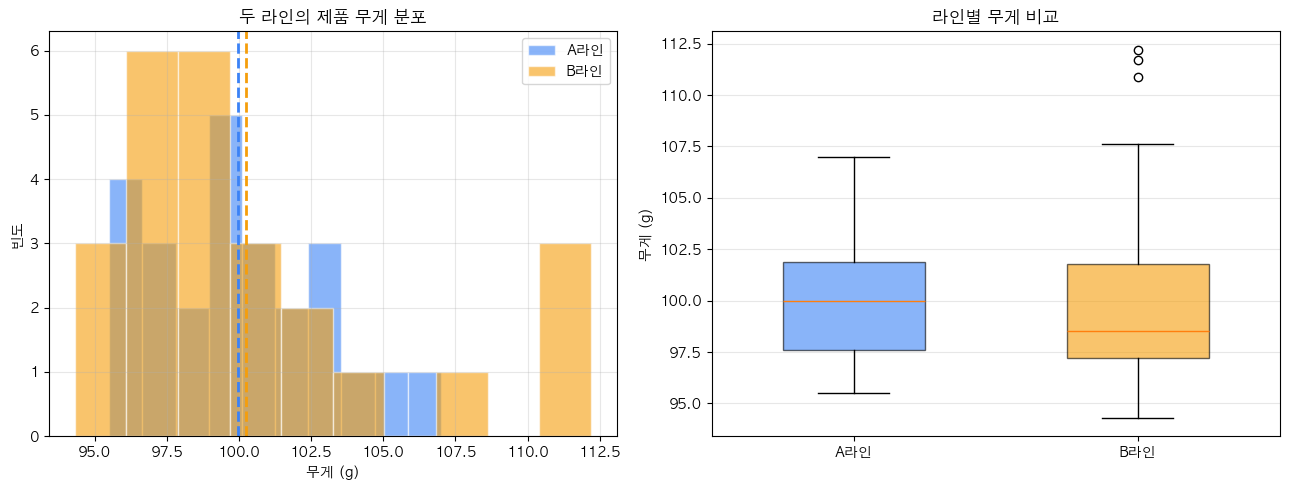

In [9]:
# 시각화: 두 라인 비교
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].hist(line_a, bins=10, alpha=0.6, color='#3B82F6', edgecolor='white', label='A라인')
axes[0].hist(line_b, bins=10, alpha=0.6, color='#F59E0B', edgecolor='white', label='B라인')
axes[0].axvline(np.mean(line_a), color='#3B82F6', linestyle='--', linewidth=2)
axes[0].axvline(np.mean(line_b), color='#F59E0B', linestyle='--', linewidth=2)
axes[0].set_xlabel('무게 (g)')
axes[0].set_ylabel('빈도')
axes[0].set_title('두 라인의 제품 무게 분포', fontsize=12, fontweight='bold')
axes[0].legend(fontsize=10)
axes[0].grid(alpha=0.3)

bp = axes[1].boxplot([line_a, line_b], labels=['A라인', 'B라인'],
                      patch_artist=True, widths=0.5)
bp['boxes'][0].set_facecolor('#3B82F6')
bp['boxes'][0].set_alpha(0.6)
bp['boxes'][1].set_facecolor('#F59E0B')
bp['boxes'][1].set_alpha(0.6)
axes[1].set_ylabel('무게 (g)')
axes[1].set_title('라인별 무게 비교', fontsize=12, fontweight='bold')
axes[1].grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 문제 2-1: 가설 설정 및 가정 검정

**(a)** 분석 목표에 맞는 **귀무가설(H₀)**과 **대립가설(H₁)**을 설정하세요.

**(b)** **양측검정** 또는 **단측검정** 중 어떤 것이 적절한지 결정하고, 그 근거를 설명하세요.

**(c)** 각 라인의 정규성을 검정하세요.

**(d)** 두 라인의 Q-Q Plot을 나란히 그리세요.

**(e)** 정규성이 충족된다면, 등분산 검정도 수행하세요.

**(f)** 가정 검정 결과를 종합하여 어떤 검정을 사용할지 결정하세요.

의사결정 과정을 단계별로 설명하세요.

In [ ]:
print("\n[문제 2-1] 가설 설정 및 가정 검정")
print("-" * 40)

# TODO (a): 가설 설정
print("(a) 가설 설정:")
print(f"    H₀: A라인과 B라인에서 생산된 과자의 무게에 차이가 없다")
print(f"    H₁: A라인과 B라인에서 생산된 과자의 무게에 차이가 있다")

# TODO (b): 양측/단측 결정
print(f"\n(b) 검정 방향:")
print(f"    선택: 양측검정")
print(f"    근거: 차이가 있다는 것을 검정하기 때문에 양측검정을 시행한다")

# TODO (c): 정규성 검정
stat_a = stats.shapiro(line_a)[0]
p_a = stats.shapiro(line_a)[1]
stat_b = stats.shapiro(line_b)[0]
p_b = stats.shapiro(line_b)[1]

print(f"\n(c) 정규성 검정:")
print(f"    A라인: W={stat_a}, p={p_a}") # p=0.4470797972985851 --> 정규성 채택
print(f"    B라인: W={stat_b}, p={p_b}") # p=0.000920764807221941 --> 정규성 기각



[문제 2-1] 가설 설정 및 가정 검정
----------------------------------------
(a) 가설 설정:
    H₀: A라인과 B라인에서 생산된 과자의 무게에 차이가 없다
    H₁: A라인과 B라인에서 생산된 과자의 무게에 차이가 있다

(b) 검정 방향:
    선택: 양측검정
    근거: 차이가 있다는 것을 검정하기 때문에 양측검정을 시행한다

(c) 정규성 검정:
    A라인: W=0.961591650383214, p=0.4470797972985851
    B라인: W=0.8348553450968029, p=0.000920764807221941


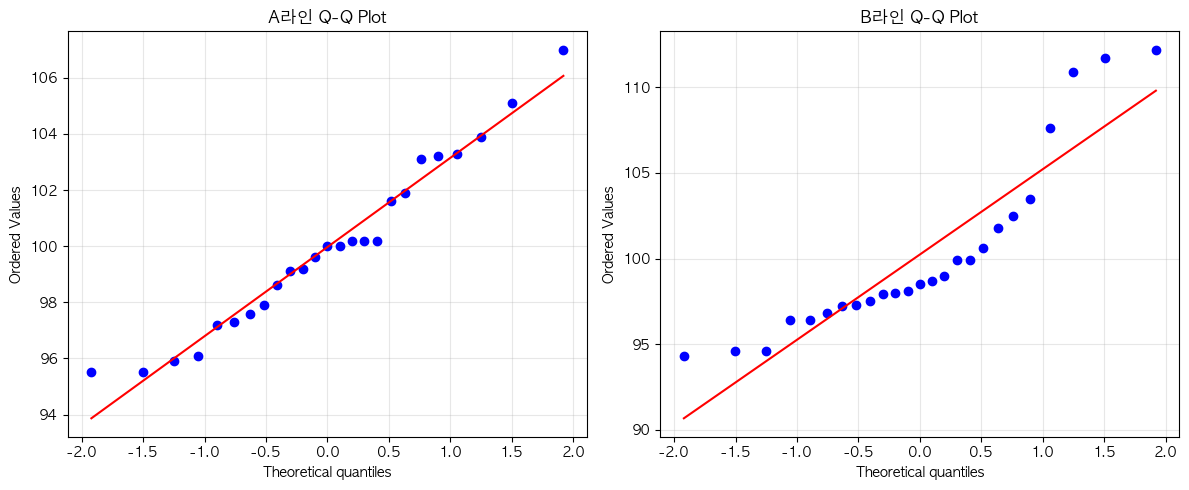

In [43]:
# TODO (d): Q-Q Plot
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# TODO: 각 라인의 Q-Q Plot 그리기

stats.probplot(line_a, plot=axes[0])
stats.probplot(line_b, plot=axes[1])

axes[0].set_title("A라인 Q-Q Plot", fontsize=12, fontweight="bold")
axes[0].grid(alpha=0.3)
axes[1].set_title("B라인 Q-Q Plot", fontsize=12, fontweight="bold")
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


In [ ]:
# TODO (e): 등분산 검정 (정규성 충족 시)
lev_stat = stats.levene(line_a, line_b)[0]
lev_p = stats.levene(line_a, line_b)[1]

print(f"(e) 등분산 검정:")
print(f"    F={lev_stat}, p={lev_p}") # F=1.6507296774763391, p=0.2050253523859501
print(f"    판정: p-value가 0.05인 유의수준보다 높으니 등분산이 아니라는 증거가 불충분하다")

# TODO (f): 검정 방법 결정
print(f"\n(f) 검정 방법 결정:")
print(f"    [1] 정규성 — A: 정규성을 불만족할 증거가 불충분하다, B: 정규성을 불만족한다")
print(f"    [2] 등분산 — 등분산성을 불만족한다는 증거가 불충분한다")
print(f"    [3] 결론 → 사용할 검정: Mann-Whitney U 검정")


(e) 등분산 검정:
    F=1.6507296774763391, p=0.2050253523859501

(f) 검정 방법 결정:


### 문제 2-2: 검정 수행 및 효과크기

**(a)** 2-1에서 결정한 검정을 수행하세요 (α = 0.05).

**(b)** 적절한 효과크기를 계산하세요.

> 모수 검정(t-검정)이면 Cohen's d를, 비모수 검정이면 rank-biserial r을 계산합니다.

**(c)** p-value와 효과크기를 종합하여 최종 결론을 작성하세요.

In [50]:
import pingouin as pg 

print("\n[문제 2-2] 검정 수행 및 효과크기")
print("-" * 40)

# TODO (a): 검정 수행
test_stat_2 = stats.mannwhitneyu(line_a, line_b, alternative="two-sided")[0]
p_value_2 = stats.mannwhitneyu(line_a, line_b, alternative="two-sided")[1]

print(f"(a) 검정 결과:")
print(f"    검정통계량: {test_stat_2}")
print(f"    p-value: {p_value_2}") # p-value: 0.5031183792231537
print(f"    판정 (α=0.05): p-value가 유의수준보다 크기 때문에 귀무가설을 기각하지 못한다")

# TODO (b): 효과크기
# Mann-Whitney U 검정은 비모수 검정이기 때문에 rank-biserial r 계산
effect_size_2 = pg.mwu(line_a, line_b)

print(f"\n(b) 효과크기: \n{effect_size_2}") # 0.503118
print(f"    해석 (작은/중간/큰): 효과크기가 0.5 이상이므로 크다")

# TODO (c): 종합 결론
print(f"\n(c) 종합 결론:")
print(f"    맨휘트니 U검정을 했을 때 p-value가 유의수준보다 크게 나왔으므로 A라인과 B라인에서 생산된 과자 무게에 차이가 없다는 귀무가설을 기각할 증거가 불충분하다")
print(f"    비모수검정의 rank-biserial r 효과크기 검정 결과는 0.5 이상이므로 효과크기가 크다")
print(f"    A라인과 B라인의 과자 무게 차이를 분석한 결과, 통계적으로는 두 라인 간의 유의미한 차이가 발견되지 않았음 (p>0.05).")
print(f"    그러나 비모수 효과크기(r)가 0.5 이상으로 높게 나타난 점을 고려할 때 이는 실질적인 차이가 존재할 가능성이 있으나 현재의 표본 크기가 작아 (25) 통계적 유의성을 확보하지 못한 (낮은 검정력) 상태일 수 있음)")
print(f"    따라서 현 시점에서는 '차이가 없다'고 판정하되, 보다 정확한 판단을 위해 추가적인 표본 수집을 통한 재검증을 권고함")


[문제 2-2] 검정 수행 및 효과크기
----------------------------------------
(a) 검정 결과:
    검정통계량: 347.5
    p-value: 0.5031183792231537
    판정 (α=0.05): p-value가 유의수준보다 크기 때문에 귀무가설을 기각하지 못한다

(b) 효과크기: 
     U-val alternative     p-val    RBC   CLES
MWU  347.5   two-sided  0.503118  0.112  0.556
    해석 (작은/중간/큰): 효과크기가 0.5 이상이므로 크다

(c) 종합 결론:
    맨휘트니 U검정을 했을 때 p-value가 유의수준보다 크게 나왔으므로 A라인과 B라인에서 생산된 과자 무게에 차이가 없다는 귀무가설을 기각할 증거가 불충분하다
    비모수검정의 rank-biserial r 효과크기 검정 결과는 0.5 이상이므로 효과크기가 크다
    A라인과 B라인의 과자 무게 차이를 분석한 결과, 통계적으로는 두 라인 간의 유의미한 차이가 발견되지 않았음 (p>0.05).
    그러나 비모수 효과크기(r)가 0.5 이상으로 높게 나타난 점을 고려할 때 이는 실질적인 차이가 존재할 가능성이 있으나 현재의 표본 크기가 작아 (25) 통계적 유의성을 확보하지 못한 (낮은 검정력) 상태일 수 있음)
    따라서 현 시점에서는 '차이가 없다'고 판정하되, 보다 정확한 판단을 위해 추가적인 표본 수집을 통한 재검증을 권고함


### 문제 2-3: 모수 vs 비모수 — 왜 가정 검정이 중요한가?

**(a)** 같은 데이터에 대해 Welch's t-검정과 Mann-Whitney U 검정을 **모두** 수행하고 결과를 비교하세요.

**(b)** 두 검정의 결론이 다르다면, 어떤 검정의 결과를 더 신뢰해야 하는지 B라인의 분포 특성과 연결하여 설명하세요.

**(c)** "표본이 크면 t-검정을 써도 괜찮다"는 주장에 대해,

이 데이터의 B라인처럼 이상치가 포함된 경우에도 성립하는지 의견을 작성하세요.

In [53]:
print("\n[문제 2-3] 모수 vs 비모수 비교")
print("-" * 40)

# TODO (a): 두 검정 비교

# Welch's t-검정 (정규성 만족, 등분산성 불만족)
t_stat_comp = stats.ttest_ind(line_a, line_b, equal_var=False, alternative="two-sided")[0]
p_t_comp = stats.ttest_ind(line_a, line_b, equal_var=False, alternative="two-sided")[1]

# Mann-Whitney U 검정 (정규성 불만족)
u_stat_comp = stats.mannwhitneyu(line_a, line_b, alternative="two-sided")[0]
p_u_comp = stats.mannwhitneyu(line_a, line_b, alternative="two-sided")[1]

print(f"(a) 검정 결과 비교:")
print(f"    Welch's t: t={t_stat_comp}, p={p_t_comp}") # t=-0.22167795570919085, p=0.8257196834842396
print(f"    Mann-Whitney U: U={u_stat_comp}, p={p_u_comp}") # U: U=347.5, p=0.5031183792231537

# TODO (b): 해석
print(f"\n(b) 어떤 검정을 더 신뢰해야 하나요?")
print(f"    이 사례의 경우 line_b가 정규성을 만족하지 않으므로 실제 수치값보다는 순위 정보를 이용하는 Mann-Whitney U 검정이 더 강건함")
print(f"    특히 t-검정의 p-value가 지나치게 높게 나온 것은 분포의 왜곡이나 이상치가 분산을 과다 추정하게 만들어 '차이가 없다'고 잘못 판단(제2종 오류)했을 가능성을 시사함")

# TODO (c): CLT와 이상치
print(f"\n(c) 이상치가 있을 때 t-검정의 한계:")
print(f"    극단적 이상치가 있으면 평균과 분산이 왜곡되므로, t-검정의 결과의 검정력이 떨어질 수 있어서 순위 기반 비모수 검정이 더 유용함")
print(f"    표본 크기가 커지면(CLT) 평균의 분포는 정규성을 띠지만, 이상치로 인한 '분산의 왜곡' 문제까지 해결해 주지는 못하므로 순위 기반 비모수 검정이 더 강건함")



[문제 2-3] 모수 vs 비모수 비교
----------------------------------------
(a) 검정 결과 비교:
    Welch's t: t=-0.22167795570919085, p=0.8257196834842396
    Mann-Whitney U: U=347.5, p=0.5031183792231537

(b) 어떤 검정을 더 신뢰해야 하나요?
    이 사례의 경우 line_b가 정규성을 만족하지 않으므로 실제 수치값보다는 순위 정보를 이용하는 Mann-Whitney U 검정이 더 강건함
    특히 t-검정의 p-value가 지나치게 높게 나온 것은 분포의 왜곡이나 이상치가 분산을 과다 추정하게 만들어 '차이가 없다'고 잘못 판단(제2종 오류)했을 가능성을 시사함

(c) 이상치가 있을 때 t-검정의 한계:
    극단적 이상치가 있으면 평균과 분산이 왜곡되므로, t-검정의 결과의 검정력이 떨어질 수 있어서 순위 기반 비모수 검정이 더 유용함
    표본 크기가 커지면(CLT) 평균의 분포는 정규성을 띠지만, 이상치로 인한 '분산의 왜곡' 문제까지 해결해 주지는 못하므로 순위 기반 비모수 검정이 더 강건함


---

## 문제 3: 요일별 고객 방문 패턴 분석

한 음식점 사장이 "요일에 따라 방문 고객 수가 다르지 않다"고 주장합니다.

한 주간 방문 고객 수를 조사하여 이 주장을 검증합니다.

총 **420명**의 고객이 방문했습니다.

**분석 목표**: 요일별 고객 방문 비율이 균등(각 1/7)한지 검정합니다.

**주어진 데이터:**

In [ ]:
print("\n[문제 3] 요일별 고객 방문 패턴 분석") # 카이제곱 적합도검정
print("=" * 50)

np.random.seed(503)
days = ['월', '화', '수', '목', '금', '토', '일']
true_probs = [0.10, 0.10, 0.12, 0.12, 0.16, 0.22, 0.18]
visits = np.random.choice(days, size=420, p=true_probs)
observed_visits = np.array([np.sum(visits == d) for d in days])

print(f"요일별 방문 고객 수 (총 {observed_visits.sum()}명):")
df_visits = pd.DataFrame({'요일': days, '관측 빈도': observed_visits})
display(df_visits)



[문제 3] 요일별 고객 방문 패턴 분석
요일별 방문 고객 수 (총 420명):


,요일,관측 빈도
0,월,50
1,화,43
2,수,40
3,목,54
4,금,69
5,토,89
6,일,75


### 문제 3-1: 가설 설정 및 적합도 검정

**(a)** 분석 목표에 맞는 **귀무가설(H₀)** 과 **대립가설(H₁)** 을 설정하세요.

> 카이제곱 검정은 "차이가 존재하는가?"를 판정하므로 양측/단측 개념이 적용되지 않습니다.

**(b)** 기대빈도를 계산하고, Cochran's rule을 확인하세요.

기대빈도 < 5인 셀이 전체의 20%를 초과하거나 기대빈도 < 1인 셀이 있는지 점검하세요.

**(c)** 적합도 검정을 수행하세요 (α = 0.05).

**(d)** 결론을 내리세요.

In [62]:
print("\n[문제 3-1] 가설 설정 및 적합도 검정")
print("-" * 40)

# TODO (a): 가설 설정
print("(a) 가설 설정:")
print(f"    H₀: 요일별 방문 고객 수가 기대빈도인 1/7과 일치한다")
print(f"    H₁: 요일별 실제 방문 고객 수와 기대빈도 사이에 차이가 존재한다")

# TODO (b): 기대빈도 + Cochran's rule 확인
n_total_visits = observed_visits.sum()
expected_visits = n_total_visits / (len(days)) # 균등 분포 가정 하의 기대빈도

print(f"\n(b) 기대빈도: {expected_visits}")

# Cochran's rule 점검
print(f"    기대 빈도가 모두 5 이상이므로 조건 충족!")

# TODO (c): 적합도 검정
chi2_visits = stats.chisquare(observed_visits, expected_visits)[0]
p_visits = stats.chisquare(observed_visits)[1]

print(f"\n(c) 적합도 검정:")
print(f"    χ² = {chi2_visits}")
print(f"    자유도 (df) = {len(days) - 1}")
print(f"    p-value = {p_visits}") 
#     χ² = 32.86666666666667
#     자유도 (df) = 6
#     p-value = 1.1123757485602509e-05

# TODO (d): 결론
print(f"\n(d) 결론 (α=0.05):")
print(f"    카이제곱 적합도 검정의 p-value가 유의수준보다 낮으므로 귀무가설을 기각하고 즉, 실제 빈도가 기대 빈도와 같지 않고 둘 사이에 차이가 존재한다고 할 수 있다")
print(f"    이는 요일별 방문 고객이 일정하지 않고 특정 요일에 집중되는 경향이 있다는 의미로 인력 배치나 재고 관리를 요일별로 차별화할 필요 있음")


[문제 3-1] 가설 설정 및 적합도 검정
----------------------------------------
(a) 가설 설정:
    H₀: 요일별 방문 고객 수가 기대빈도인 1/7과 일치한다
    H₁: 요일별 실제 방문 고객 수와 기대빈도 사이에 차이가 존재한다

(b) 기대빈도: 60.0
    기대 빈도가 모두 5 이상이므로 조건 충족!

(c) 적합도 검정:
    χ² = 32.86666666666667
    자유도 (df) = 6
    p-value = 1.1123757485602509e-05

(d) 결론 (α=0.05):
    카이제곱 적합도 검정의 p-value가 유의수준보다 낮으므로 귀무가설을 기각하고 즉, 실제 빈도가 기대 빈도와 같지 않고 둘 사이에 차이가 존재한다고 할 수 있다
    이는 요일별 방문 고객이 일정하지 않고 특정 요일에 집중되는 경향이 있다는 의미로 인력 배치나 재고 관리를 요일별로 차별화할 필요 있음


### 문제 3-2: 효과크기와 사후분석 (잔차 분석)

**(a)** 효과크기(Cohen's w)를 계산하고 해석하세요.

**(b)** 표준화 잔차를 계산하세요.

**각 요일**에 대해 잔차 값과 방향(기대보다 많음/적음)을 보고하세요.

> 표준화 잔차 = (O − E) / √E

**(c)** |잔차| > 2인 요일을 찾고, 이 요일들이 왜 기대와 다른지 실생활 관점에서 해석하세요.

**(d)** 관측 빈도와 기대 빈도를 비교하는 막대 그래프를 그리세요.

In [66]:
print("\n[문제 3-2] 효과크기와 사후분석")
print("-" * 40)

# TODO (a): Cohen's w
cohens_w_visits = np.sqrt(chi2_visits / observed_visits.sum())

print(f"(a) Cohen's w = {cohens_w_visits}") # 0.279739107480467
print(f"    해석: {cohens_w_visits}이 0.3보다 작기 때문에 작은 수준의 효과크기다")

# TODO (b): 표준화 잔차
# 잔차 : 카이제곱 검정 통계량 구할 때 수식의 시그마를 제외한 그 값의 루트
print(f"\n(b) 사후분석 — 표준화 잔차:")
std_residuals = (observed_visits - expected_visits) / np.sqrt(expected_visits)
print(f"    잔차: {std_residuals}")
# [-1.29099445 -2.19469056 -2.5819889  -0.77459667  1.161895  3.7438839  1.93649167]

# TODO (c): 해석
print(f"\n(c) |잔차| > 2인 요일 해석:")
print(f"    화, 수, 토요일의 잔차의 절댓값이 2 이상이다")
print(f"    위 세 요일의 결과가 기대빈도와 유의하게 다르다고 할 수 있다")
print(f"    특히 토요일은 잔차가 {std_residuals[5]:.2f}로 기대빈도보다 훨씬 방문 고객 수가 급증하는 피크타임으로 밝혀졌다")
print(f"    이와 달리 화요일과 수요일은 {std_residuals[1]:.2f}, {std_residuals[2]:.2f}로 기대빈도보다 유의하게 적은 고객이 방문하는 것으로 밝혀졌다")


[문제 3-2] 효과크기와 사후분석
----------------------------------------
(a) Cohen's w = 0.279739107480467
    해석: 0.279739107480467이 0.3보다 작기 때문에 작은 수준의 효과크기다

(b) 사후분석 — 표준화 잔차:
    잔차: [-1.29099445 -2.19469056 -2.5819889  -0.77459667  1.161895    3.7438839
  1.93649167]

(c) |잔차| > 2인 요일 해석:
    화, 수, 토요일의 잔차의 절댓값이 2 이상이다
    위 세 요일의 결과가 기대빈도와 유의하게 다르다고 할 수 있다
    특히 토요일은 잔차가 3.74로 기대빈도보다 훨씬 방문 고객 수가 급증하는 피크타임으로 밝혀졌다
    이와 달리 화요일과 수요일은 -2.19, -2.58로 기대빈도보다 유의하게 적은 고객이 방문하는 것으로 밝혀졌다


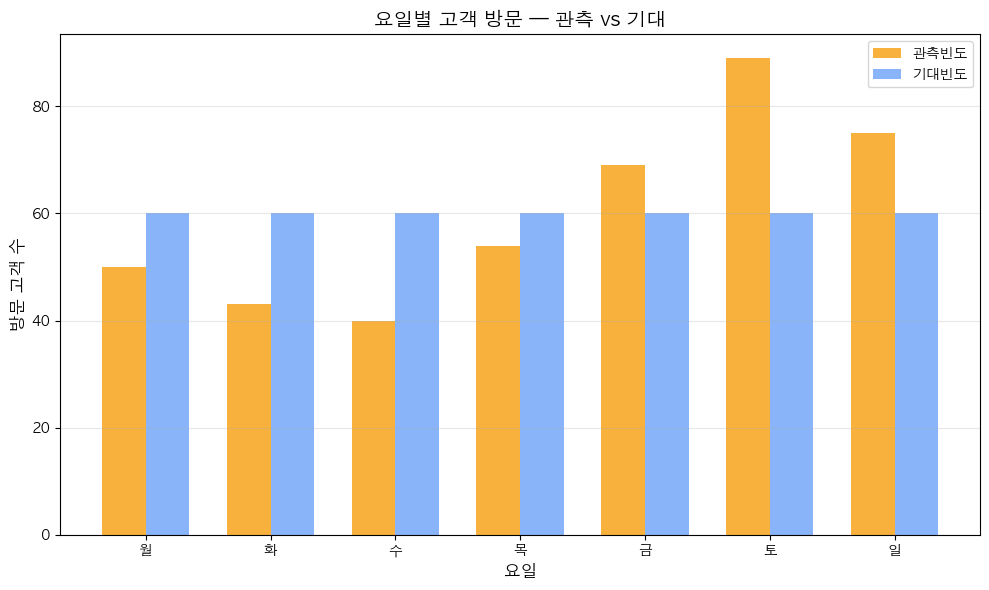

In [69]:
# TODO (d): 관측 vs 기대 빈도 막대 그래프
fig, ax = plt.subplots(figsize=(10, 6))
x = np.arange(len(days))
width = 0.35

# TODO: 관측/기대 빈도 나란히 막대 그래프

expected_visits = [expected_visits] * len(days)

# 관측값은 왼쪽으로(x - width/2), 기대값은 오른쪽으로(x + width/2) 밀어줌
rects1 = ax.bar(x - width/2, observed_visits, width, label='관측빈도', color='#F59E0B', alpha=0.8)
rects2 = ax.bar(x + width/2, expected_visits, width, label='기대빈도', color='#3B82F6', alpha=0.6)

ax.set_xlabel('요일', fontsize=12)
ax.set_ylabel('방문 고객 수', fontsize=12)
ax.set_title('요일별 고객 방문 — 관측 vs 기대', fontsize=14, fontweight='bold')
ax.set_xticks(x)
ax.set_xticklabels(days)
ax.legend()
ax.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.show()


### 문제 3-3: 소규모 카페 음료 선호도

위와 별개 상황입니다. 한 소규모 카페에서 5가지 음료의 선호도가 균등한지 조사했습니다.

총 **22명**의 고객이 응답했습니다.

**분석 목표**: 5가지 음료의 선호도가 균등(각 1/5)한지 검정합니다.

**주어진 데이터:**

In [19]:
print("\n[문제 3-3] 소규모 카페 음료 선호도")
print("-" * 40)

menu = ['아메리카노', '라떼', '카푸치노', '스무디', '에이드']
observed_small = np.array([8, 5, 4, 3, 2])
n_total_small = observed_small.sum()

print(f"음료별 선호 고객 수 (총 {n_total_small}명):")
df_small = pd.DataFrame({'음료': menu, '관측 빈도': observed_small})
display(df_small)



[문제 3-3] 소규모 카페 음료 선호도
----------------------------------------
음료별 선호 고객 수 (총 22명):


,음료,관측 빈도
0,아메리카노,8
1,라떼,5
2,카푸치노,4
3,스무디,3
4,에이드,2


**(a)** 가설을 설정하세요.

**(b)** 균등 분포를 가정할 때 기대빈도를 계산하고, Cochran's rule을 점검하세요. 조건이 충족되나요?

**(c)** Cochran's rule이 위반되면, 사용할 수 있는 대안 방법은 무엇인가요?
  - 범주 병합과 Monte Carlo 시뮬레이션 중 어떤 것이 이 상황에 더 적절한지 설명하세요.

**(d)** 선택한 대안 방법을 적용하여 검정을 수행하세요.

**(e)** 효과크기(Cohen's w)를 계산하고 해석하세요.

In [ ]:
# TODO (a): 가설 설정
print("(a) 가설 설정:")
print(f"    H₀: 음료의 판매 관측 빈도가 기대 빈도와 일치할 것이다")
print(f"    H₁: 실제 음료의 판매 빈도와 기대 빈도 사이에 차이가 존재할 것이다")

# TODO (b): 기대빈도 + Cochran's rule
expected_small = np.array([n_total_small / len(menu)] * len(menu)) # 균등 분포: n_total / 5

print(f"\n(b) 기대빈도: {expected_small}")
print(f"    기대빈도 < 5인 셀: 5개 (100%)")
print(f"    Cochran's rule: 조건을 충족하지 않는다!")

ch2, p = stats.chisquare(observed_small, expected_small)

# TODO (c): 대안 방법 선택
print(f"\n(c) 대안 방법:")
print(f"     Monte Carlo 시뮬레이션")

# TODO (d): 검정 수행 (선택한 대안)
# Monte Carlo 시뮬레이션을 직접 구현하거나, 범주 병합 후 검정
# n_total_small
expected_prob = expected_small / n_total_small

np.random.seed(42)

sample = np.random.multinomial(n_total_small, expected_prob)

n_simulation = 100_000 # 십만번 반복
count_extreme = 0 # 극단값의 개수
for _ in range(n_simulation) :

    # 귀무가설이 참이라는 가정하에 샘플링
    sample = np.random.multinomial(n_total_small, expected_prob) # 한번 시행마다 균일분포에서 22개씩 추출

    # 시뮬레이션 데이터의 카이제곱 통계량 계산
    chi_sim = np.sum((sample - expected_small) ** 2 / expected_small)
    if chi_sim > ch2 : # 우리가 직접 설문조사한 ch2값보다 크면 극단적인 경우라고 가정
        count_extreme += 1


p_alternative = count_extreme / n_simulation

print(f"\n(d) 검정 결과:")
print(f"    p-value: {p_alternative}") # 0.27533
print(f"    판정 (α=0.05): p-value가 {p_alternative:.3f}으로 유의수준보다 높기 때문에 귀무가설을 기각할 증거가 부족하다")
print(f"    따라서 음료의 실제 판매 관측 빈도와 기대 빈도 사이에 차이가 존재할 것이라고 볼 증거가 불충분하다")

# TODO (e): 효과크기
cohens_w_small = np.sqrt(ch2 / n_total_small)
size_w = '작은' if cohens_w_small < 0.3 else '중간' if cohens_w_small < 0.5 else '큰'

print(f"\n(e) Cohen's w = {cohens_w_small}") # 0.4679831882266818
print(f"    해석: 효과크기는 {cohens_w_small:.3f}로 {size_w} 효과를 보인다")
print(f"    효과크기는 실무적으로 의미 있는 차이를 시사하지만, 표본 크기가 너무 작아 통계적 유의성을 확보하지 못했다")
print(f"    차이가 실제로 존재하는지 확인하기 위해 더 많은 표본 데이터 수집이 필요하다")


(a) 가설 설정:
    H₀: 음료의 판매 관측 빈도가 기대 빈도와 일치할 것이다
    H₁: 실제 음료의 판매 빈도와 기대 빈도 사이에 차이가 존재할 것이다

(b) 기대빈도: [4.4 4.4 4.4 4.4 4.4]
    기대빈도 < 5인 셀: 5개 (100%)
    Cochran's rule: 조건을 충족하지 않는다!

(c) 대안 방법:
     Monte Carlo 시뮬레이션

(d) 검정 결과:
    p-value: 0.27533
    판정 (α=0.05): p-value가 0.273으로 유의수준보다 높기 때문에 음료의 실제 판매 관측 빈도와 기대 빈도 사이에 차이가 존재할 것으로 예상된다

(e) Cohen's w = 0.4679831882266818
    해석: 효과크기는 0.468로 중간 효과를 보인다


---

## 문제 4: 연령대별 운동 선호도 조사

헬스장에서 연령대(20대/30대/40대)에 따라 선호하는 운동 종류(헬스/요가/수영)가 다른지 조사합니다.

총 **180명**을 대상으로 설문을 실시했습니다.

**분석 목표**: 연령대에 따라 선호하는 운동 종류에 유의한 차이가 있는지 검정합니다.

**주어진 데이터:**

In [21]:
print("\n[문제 4] 연령대별 운동 선호도 조사")
print("=" * 50)

np.random.seed(504)
n_survey = 180

ages = np.random.choice(['20대', '30대', '40대'], size=n_survey, p=[0.35, 0.35, 0.30])

exercise_prefs = []
for age in ages:
    if age == '20대':
        exercise_prefs.append(np.random.choice(['헬스', '요가', '수영'], p=[0.50, 0.20, 0.30]))
    elif age == '30대':
        exercise_prefs.append(np.random.choice(['헬스', '요가', '수영'], p=[0.30, 0.40, 0.30]))
    else:
        exercise_prefs.append(np.random.choice(['헬스', '요가', '수영'], p=[0.20, 0.35, 0.45]))
exercise_prefs = np.array(exercise_prefs)

df_survey = pd.DataFrame({'연령대': ages, '운동': exercise_prefs})

ct_exercise = pd.crosstab(df_survey['연령대'], df_survey['운동'],
                            margins=True, margins_name='합계')
print("\n교차표:")
display(ct_exercise)



[문제 4] 연령대별 운동 선호도 조사

교차표:


운동,수영,요가,헬스,합계
연령대,,,,
20대,18,19,29,66
30대,19,22,19,60
40대,29,16,9,54
합계,66,57,57,180


### 문제 4-1: 가설 설정 및 독립성 검정

**(a)** 분석 목표에 맞는 **귀무가설(H₀)** 과 **대립가설(H₁)** 을 설정하세요.

**(b)** 기대빈도를 계산하고 표로 출력하세요.

  - Cochran's rule(기대빈도 < 5인 셀이 20% 이하, 기대빈도 < 1인 셀이 0개)을 점검하세요.

**(c)** 조건 충족 여부에 따라 적절한 검정을 수행하세요 (α = 0.05).

**(d)** 결론을 내리세요.

In [22]:
print("\n[문제 4-1] 가설 설정 및 독립성 검정")
print("-" * 40)

ct_raw_ex = pd.crosstab(df_survey['연령대'], df_survey['운동'])

# TODO (a): 가설 설정
print("(a) 가설 설정:")
# print(f"    H₀: ...")
# print(f"    H₁: ...")

# TODO (b): 기대빈도 + Cochran's rule
chi2_ex = None
p_ex = None
dof_ex = None
expected_ex = None

print(f"\n(b) 기대빈도:")

# Cochran's rule 점검


# TODO (c): 검정 수행
print(f"\n(c) 독립성 검정:")
print(f"    χ² = {chi2_ex}")
print(f"    자유도 (df) = {dof_ex}")
print(f"    p-value = {p_ex}")

# TODO (d): 결론
print(f"\n(d) 결론 (α=0.05):")
# print(f"    ...")



[문제 4-1] 가설 설정 및 독립성 검정
----------------------------------------
(a) 가설 설정:

(b) 기대빈도:

(c) 독립성 검정:
    χ² = None
    자유도 (df) = None
    p-value = None

(d) 결론 (α=0.05):


### 문제 4-2: 효과크기와 사후분석 (조정된 잔차)

**(a)** Cramér's V를 계산하고 해석하세요.

df* = min(r−1, c−1)에 따른 해석 기준을 적용하세요.

**(b)** 조정된 잔차(표준화 잔차)를 구하고 표로 출력하세요.

**(c)** 각 셀이 의미하는 바를 구체적으로 해석하세요.
> 예: "20대 × 헬스: 잔차 = +2.5 → 20대는 기대보다 헬스를 더 많이 선호합니다"

**(d)** 관측 빈도와 기대 빈도를 비교하는 히트맵을 나란히 그리세요.

In [23]:
print("\n[문제 4-2] 효과크기와 사후분석")
print("-" * 40)

# TODO (a): Cramér's V
r_ex, c_ex = ct_raw_ex.shape
df_star_ex = min(r_ex - 1, c_ex - 1)

cramers_v_ex = None

print(f"(a) Cramér's V = {cramers_v_ex}")
print(f"    df* = {df_star_ex}")
# Cramér's V 해석 기준 (df*에 따라 계산)
# print(f"    해석: ...")

# TODO (b): 조정된 잔차
# 조정된 잔차를 계산하여 DataFrame으로 만드세요
std_res_ex = None

print(f"\n(b) 조정된 잔차:")

# TODO (c): |잔차| > 2인 셀 해석
print(f"\n(c) |잔차| > 2인 셀:")



[문제 4-2] 효과크기와 사후분석
----------------------------------------
(a) Cramér's V = None
    df* = 2

(b) 조정된 잔차:

(c) |잔차| > 2인 셀:


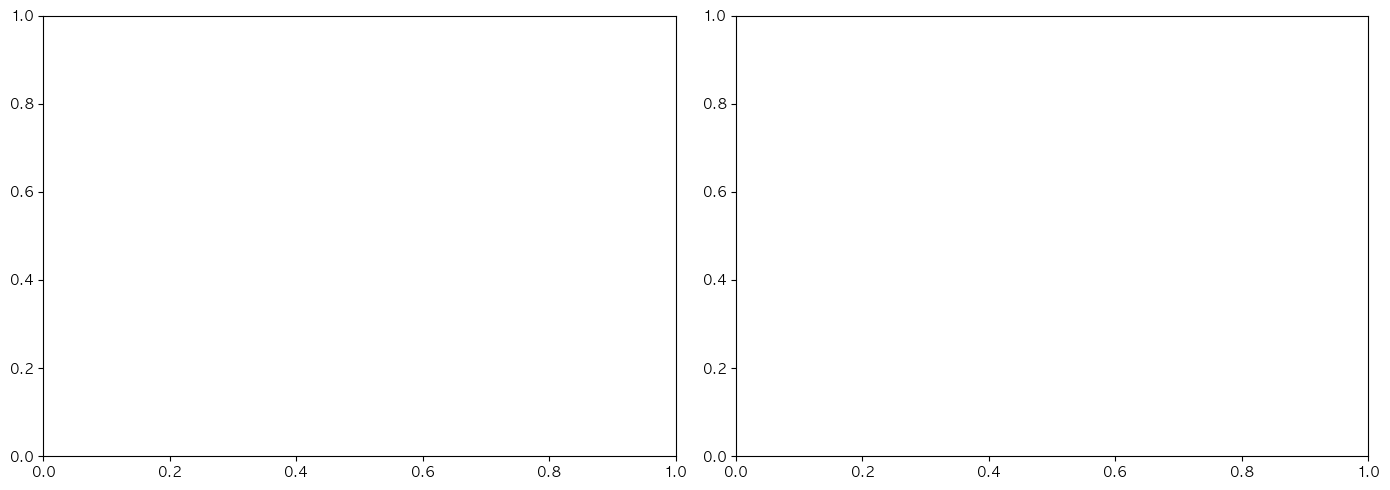

In [24]:
# TODO (d): 히트맵 시각화 (관측 빈도 vs 기대 빈도)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# TODO: 관측 빈도 히트맵

# TODO: 기대 빈도 히트맵


plt.tight_layout()
plt.show()


### 문제 4-3: 면접 방식별 합격률

위 데이터와 별개로, 한 중소기업 인사팀에서 **면접 방식**(대면/화상)에 따라

최종 합격률이 다른지 파악하려 합니다.

소규모 채용 회차로 총 **20명**의 지원자 데이터입니다.

**분석 목표**: 면접 방식(대면/화상)에 따라 최종 합격률에 유의한 차이가 있는지 검정합니다.

**주어진 데이터:**

In [25]:
print("\n[문제 4-3] 면접 방식별 합격률")
print("-" * 40)

# 2×2 교차표
#              합격    불합격
# 대면 면접     7       3      = 10
# 화상 면접     2       8      = 10
#               9      11      = 20
data_fisher_q4 = np.array([[7, 3],
                             [2, 8]])

ct_fisher_q4 = pd.DataFrame(data_fisher_q4,
                              index=['대면 면접', '화상 면접'],
                              columns=['합격', '불합격'])
ct_display_q4 = ct_fisher_q4.copy()
ct_display_q4['합계'] = ct_display_q4.sum(axis=1)
ct_display_q4.loc['합계'] = ct_display_q4.sum()
print("교차표:")
display(ct_display_q4)



[문제 4-3] 면접 방식별 합격률
----------------------------------------
교차표:


,합격,불합격,합계
대면 면접,7,3,10
화상 면접,2,8,10
합계,9,11,20


**(a)** **귀무가설(H₀)** 과 **대립가설(H₁)** 을 설정하세요.

**(b)** **양측검정** 또는 **단측검정** 중 어떤 것이 적절한지 결정하고, 그 근거를 설명하세요.

> Fisher 정확검정에서는 양측/단측 선택이 결과에 직접 영향을 줍니다.

**(c)** 기대빈도를 계산하고 Cochran's rule을 점검하세요.

카이제곱 검정을 적용할 수 있는지 판단하세요.

**(d)** 적절한 검정을 선택하여 수행하세요 (α = 0.05).

왜 이 검정을 선택했는지 이유를 설명하세요.

**(e)** 오즈비(OR)를 구하고 해석하세요.

> 오즈(Odds) = 해당 사건 / 반대 사건 \
> 오즈비(OR) = 한 집단의 오즈 / 다른 집단의 오즈 \
> 예: 대면 면접의 합격 오즈 = 합격 / 불합격

**(f)** 효과크기 φ(Phi) 계수를 계산하고 해석하세요.

In [26]:
# TODO (a): 가설 설정
print("(a) 가설 설정:")
# print(f"    H₀: ...")
# print(f"    H₁: ...")

# TODO (b): 양측/단측 결정
print(f"\n(b) 검정 방향:")
# print(f"    선택: 양측검정 / 단측검정")
# print(f"    근거: ...")

# TODO (c): 기대빈도 + Cochran's rule
chi2_q4 = None
p_chi2_q4 = None
dof_q4 = None
expected_q4 = None

print(f"\n(c) 기대빈도:")
# print(f"    Cochran's rule: ...")
# print(f"    카이제곱 적용 가능 여부: ...")

# TODO (d): 검정 수행
odds_ratio_q4 = None
fisher_p_q4 = None

print(f"\n(d) 검정 결과:")
print(f"    p-value = {fisher_p_q4}")
# print(f"    판정 (α=0.05): ...")
# print(f"    검정 선택 이유: ...")

# TODO (e): 오즈비 해석
print(f"\n(e) 오즈비:")
print(f"    OR = {odds_ratio_q4}")


# TODO (f): Phi 계수
phi_q4 = None

print(f"\n(f) Phi 계수(φ) = {phi_q4}")
# print(f"    해석: ...")



(a) 가설 설정:

(b) 검정 방향:

(c) 기대빈도:

(d) 검정 결과:
    p-value = None

(e) 오즈비:
    OR = None

(f) Phi 계수(φ) = None
